##### This notebook creates STDNN-FP (pytorch) for classification prediction on Tox21

Using split data already saved.

Notebook shows results for seed = 124, but we also ran on seed 122, 123. 

Before use define desired pathways to save models,:
- path variable, in "Create checkpoint" section for models
- writer variable, in "Train the neural network model" section for tensorboard summary

In [2]:
# general and data handling
import numpy as np
import pandas as pd
import os
from collections import Counter

# Required RDKit modules
import rdkit as rd
from rdkit import DataStructs
from rdkit.Chem import AllChem

# modeling
import sklearn as sk
from sklearn.model_selection import train_test_split

# Graphing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import time
import random
import joblib

In [3]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [4]:
import torch
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")  

In [5]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [6]:
# To ensure runs on GPU
import tensorflow as tf
import datetime, os

2026-04-15 17:05:04.218737: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 17:05:04.310895: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-15 17:05:04.783343: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-15 17:05:08.052754: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Settings

In [7]:
# set seed value
seed_value = 124 #122 123 124, as used in MoleculeNet
torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)
torch.backends.cudnn.enabled=False
torch.backends.cudnn.deterministic=True

In [8]:
# number of bits for morgan fingerprints
morgan_bits = 4096

In [9]:
# number of radius for morgan fingerprints
morgan_radius = 2

In [10]:
train_epoch = 50 

In [11]:
batch = 512 

##### Load raw data

In [12]:
tox21_file  = '../../../../data/datasets/tox21/raw_data/tox21.csv'
tox21_tasks = ['NR-AR', 'NR-Aromatase', 'NR-PPAR-gamma', 'SR-HSE', 
               'NR-AR-LBD', 'NR-ER', 'SR-ARE', 'SR-MMP',
               'NR-AhR', 'NR-ER-LBD', 'SR-ATAD5', 'SR-p53']

tox21_data = pd.read_csv(tox21_file)
print('Reading {}... {} data loaded.'.format(tox21_file, len(tox21_data)))
tox21_data.head()

Reading ../../../../data/datasets/tox21/raw_data/tox21.csv... 8014 data loaded.


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,TOX3028,CC(O)(P(=O)(O)O)P(=O)(O)O


#####  Setting all tasks 

In [13]:
data = [tox21_data] 

In [14]:
all_tasks = tox21_tasks 

##### Load split data

In [3]:
# load saved tox21 train/test/valid data 
# Load and split clintox data using seed_124
# Since the pickled .pth files have pandas compatibility issues, 
# we'll recreate the splits from raw CSV

tox21_raw_file = "../../../../data/datasets/tox21/raw_data/tox21.csv"
tox21_data_path = "../../../../data/datasets/tox21/split_data/seed_124/"

# Load raw data
tox21_raw = pd.read_csv(tox21_raw_file)
print(f"Raw data loaded: {len(tox21_raw)} samples")
print(tox21_raw.head())

# Create splits using seed 124 (same as MoleculeNet)
# MoleculeNet uses 80% train, 10% valid, 10% test split
from sklearn.model_selection import train_test_split

seed = 124

# First split: 80% train, 20% temp (for valid+test)
train_data, temp_data = train_test_split(
    tox21_raw, 
    test_size=0.2, 
    random_state=seed
)

# Second split: split the 20% into 50-50 for valid and test
valid_data, test_data = train_test_split(
    temp_data, 
    test_size=0.5, 
    random_state=seed
)

print(f"\nData split sizes:")
print(f"  Train: {len(train_data)}")
print(f"  Valid: {len(valid_data)}")
print(f"  Test:  {len(test_data)}")

# Convert to DataFrames (they should already be)
train_data = train_data.reset_index(drop=True)
valid_data = valid_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

data = [train_data, test_data, valid_data]
print("\n✓ Data splits created successfully!")

Raw data loaded: 8014 samples
   NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0    0.0        0.0     1.0           NaN    NaN        0.0            0.0   
1    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
2    NaN        NaN     NaN           NaN    NaN        NaN            NaN   
3    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
4    0.0        0.0     NaN           0.0    0.0        0.0            0.0   

   SR-ARE  SR-ATAD5  SR-HSE  SR-MMP  SR-p53   mol_id  \
0     1.0       0.0     0.0     0.0     0.0  TOX3021   
1     NaN       0.0     NaN     0.0     0.0  TOX3020   
2     0.0       NaN     0.0     NaN     NaN  TOX3024   
3     NaN       0.0     NaN     0.0     0.0  TOX3027   
4     0.0       0.0     0.0     NaN     0.0  TOX3028   

                                              smiles  
0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1  
1                          CCN1C(=O)NC(c2ccccc2)C1=O  

In [16]:
print("Total number of examples, train: " + str(data[0].shape[0]))
print("Total number of examples, test: " + str(data[1].shape[0]))
print("Total number of examples, valid: " + str(data[2].shape[0]))
print("Total number of examples, train+test+valid: " + str(data[0].shape[0] + data[1].shape[0] + data[2].shape[0]))

Total number of examples, train: 6411
Total number of examples, test: 802
Total number of examples, valid: 801
Total number of examples, train+test+valid: 8014


##### <font color='blue'> Construct Morgan Fingerprints </font>

In [17]:
%%time
# construct morgan fingerprints 
for i in range(len(data)):
    data[i]['mol'] = [rd.Chem.MolFromSmiles(x) for x in data[i]['smiles']]

    bi = [{} for _ in range(len(data[i]))]
    data[i]['morgan'] = [AllChem.GetMorganFingerprintAsBitVect(data[i].iloc[j]['mol'], morgan_radius, nBits = morgan_bits, bitInfo=bi[j]) 
                         for j in range(len(data[i]))]
    data[i]['bitInfo'] = bi


[17:05:12] WARNING: not removing hydrogen atom without neighbors


[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerator
[17:05:12] DEPRECATION WARNING: please use MorganGenerat

CPU times: user 3.85 s, sys: 226 ms, total: 4.08 s
Wall time: 4.07 s


[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator
[17:05:15] DEPRECATION WARNING: please use MorganGenerator


##### Create train, test, valid sets

In [18]:
# replace NA with -1 -- used to deal with missing labels, 
#                       along with Binary Cross-Entropy loss
data[0] = data[0].fillna(-1)
data[1] = data[1].fillna(-1)
data[2] = data[2].fillna(-1)

In [19]:
train_data = data[0]
test_data  = data[1]
valid_data = data[2]

In [20]:
## Arrays for train / test / valid sets used for DNN 
# convert the RDKit explicit vectors into numpy arrays
x_train = []
for fp in train_data['morgan']:
    arr = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(fp, arr)
    x_train.append(arr)
x_train = np.array(x_train)
x_train = x_train - 0.5

y_train = train_data[all_tasks].values

In [21]:
# convert the RDKit explicit vectors into numpy arrays
x_test = []
for fp in test_data['morgan']:
    arr = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(fp, arr)
    x_test.append(arr)
x_test = np.array(x_test)
x_test = x_test - 0.5

y_test = test_data[all_tasks].values

In [22]:
# convert the RDKit explicit vectors into numpy arrays
x_valid = []
for fp in valid_data['morgan']:
    arr = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(fp, arr)
    x_valid.append(arr)
x_valid = np.array(x_valid)
x_valid = x_valid - 0.5

y_valid = valid_data[all_tasks].values

In [23]:
# count the number of data points per class
N_train = np.sum(y_train >= 0, 0)
N_test  = np.sum(y_test >= 0, 0)
N_valid  = np.sum(y_valid >= 0, 0)
#N_test_clin  = np.sum(y_clintox_test >= 0, 0)

##### Deep Neural Network (pytorch)

In [24]:
import torch
from torch.utils.data import Dataset, DataLoader

In [25]:
# convert data for pytorch
x_train_torch = x_train.astype(np.float32)
y_train_torch = y_train.astype(np.float32)

x_test_torch = x_test.astype(np.float32)
y_test_torch = y_test.astype(np.float32)

x_valid_torch = x_valid.astype(np.float32)
y_valid_torch = y_valid.astype(np.float32)

In [26]:
input_shape = x_train_torch.shape[1]
input_shape

4096

In [27]:
# Class for DNN data
class DNNData(Dataset):

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [28]:
training_set = DNNData(x_train_torch, y_train_torch)
training_generator = DataLoader(training_set, batch_size=batch, shuffle=True)

testing_set = DNNData(x_test_torch, y_test_torch)
testing_generator = DataLoader(testing_set, batch_size=len(testing_set), shuffle=False)

valid_set = DNNData(x_valid_torch, y_valid_torch)
valid_generator = DataLoader(valid_set, batch_size=len(valid_set), shuffle=False)

In [29]:
# DNN Model class
# Each 12 tasks are treated as separate tasks with 2 separate layers
class DNN(torch.nn.Module):
    def __init__(self, input_shape, all_tasks):
        super(DNN, self).__init__()

        self.hidden_1 = torch.nn.ModuleList([torch.nn.Linear(input_shape, 1024) for task in all_tasks])
        self.batchnorm_1 = torch.nn.ModuleList([torch.nn.BatchNorm1d(1024) for task in all_tasks])
        
        self.hidden_2 = torch.nn.ModuleList([torch.nn.Linear(1024, 512) for task in all_tasks])
        self.batchnorm_2 = torch.nn.ModuleList([torch.nn.BatchNorm1d(512) for task in all_tasks])
        
        self.output   = torch.nn.ModuleList([torch.nn.Linear(512, 1) for task in all_tasks])
        
        # function for leaky ReLU
        self.leakyReLU = torch.nn.LeakyReLU(0.05)

    def forward(self, x):        
        x_task = [None for i in range(len(self.output))]  # initialize
        for task in range(len(self.output)):
            x_task[task] = self.hidden_1[task](x)
            x_task[task] = self.batchnorm_1[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.hidden_2[task](x_task[task])
            x_task[task] = self.batchnorm_2[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.output[task](x_task[task])

        
        y_pred = x_task
        
        return y_pred
    
model = DNN(input_shape, all_tasks).to(device)

###### Create checkpoint - saving and loading best model 

In [30]:
import shutil
def save_ckp(state, is_best, checkpoint_path, best_model_path):
    """
    state: checkpoint we want to save
    is_best: is this the best checkpoint; min validation loss
    checkpoint_path: path to save checkpoint
    best_model_path: path to save best model
    """
    f_path = checkpoint_path
    # save checkpoint data to the path given, checkpoint_path
    torch.save(state, f_path)
    # if it is a best model, min validation loss
    if is_best:
        best_fpath = best_model_path
        # copy that checkpoint file to best path given, best_model_path
        shutil.copyfile(f_path, best_fpath)

In [31]:
def load_ckp(checkpoint_fpath, input_model, optimizer):
    """
    checkpoint_path: path to save checkpoint
    model: model that we want to load checkpoint parameters into       
    optimizer: optimizer we defined in previous training
    """
    # load check point
    checkpoint = torch.load(checkpoint_fpath)
    # initialize state_dict from checkpoint to model
    input_model.load_state_dict(checkpoint['state_dict'])
    # initialize optimizer from checkpoint to optimizer
    optimizer.load_state_dict(checkpoint['optimizer'])
    # initialize valid_loss_min from checkpoint to valid_loss_min
    train_loss_min = checkpoint['train_loss_min']
    # return model, optimizer, epoch value, min validation loss 
    return model, optimizer, checkpoint['epoch'], train_loss_min.item()

In [32]:
# Create directory to save models
import os

# Define a path where you want to save the trained models
output_dir = './trained_models/STDNN_FP_tox21_seed124'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Model output directory created: {output_dir}")

✓ Model output directory created: ./trained_models/STDNN_FP_tox21_seed124


In [33]:
path = output_dir

In [34]:
###### Pathways to save models 
checkpoint_path = path + '/current_checkpoint.pt'

#Path to saved model when train_epoch_loss <= train_loss_min
bestmodel_path = path + '/best_model.pt'  

#Path to saved model at minimum valid loss
bestmodel_byvalid = path + '/best_model_by_valid.pt' 

#Path to saved  when train_epoch_loss >= val_epoch_loss
bestmodel_byvalid_crossed = path + '/best_model_by_valid-crossed.pt'   

##### Train the neural network model

In [35]:
# Define the loss
criterion = torch.nn.BCELoss()

# Optimizers require the parameters to optimize and a learning rate
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [36]:
from torch.utils.tensorboard import SummaryWriter

# Define the desired pathway
writer = SummaryWriter('define-pathway-to-save/')

##### LOOP TO TEST DIFFERENT WEIGHTS

In [37]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

weights_list = [1,2,5,10,20,30,40,50]

results = []

os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

for task_idx, task_name in enumerate(tox21_tasks):

    print(f"\n===== TASK: {task_name} =====")

    for w in weights_list:

        print(f"Training with pos_weight = {w}")

        # fresh model per run
        model = DNN(input_shape, tox21_tasks).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = torch.nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([w]).to(device)
        )

        # ===== TRAIN =====
        for epoch in range(5):  # keep small first

            model.train()

            for x_batch, y_batch in training_generator:

                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                outputs = model(x_batch)[task_idx][:,0]
                targets = y_batch[:, task_idx]

                mask = targets >= 0

                loss = criterion(outputs[mask], targets[mask])

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # ===== EVALUATE =====
        model.eval()

        y_true = []
        y_pred = []
        y_prob = []

        with torch.no_grad():
            for x_batch, y_batch in valid_generator:

                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                outputs = model(x_batch)[task_idx][:,0]
                probs = torch.sigmoid(outputs)

                targets = y_batch[:, task_idx]
                mask = targets >= 0

                preds = (probs[mask] > 0.5).float()

                y_true.extend(targets[mask].cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
                y_prob.extend(probs[mask].cpu().numpy())

        # confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        results.append({
            "task": task_name,
            "pos_weight": w,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "roc_auc": roc_auc_score(y_true, y_prob)
        })

        # save model
        torch.save(model.state_dict(), f"models/model_{task_name}_pw{w}.pt")

# ===== SAVE CSV =====
df = pd.DataFrame(results)
df.to_csv("results_all_tasks_weights.csv", index=False)


===== TASK: NR-AR =====
Training with pos_weight = 1


KeyboardInterrupt: 

### MAIN TRAINING LOOP

In [ ]:
pos_weights = [1]*len(tox21_tasks)  # customize this

model = DNN(input_shape, tox21_tasks).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterions = [
    torch.nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([w]).to(device)
    )
    for w in pos_weights
]

for epoch in range(train_epoch):

    model.train()
    total_loss = 0

    for x_batch, y_batch in training_generator:

        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        outputs = model(x_batch)

        loss = 0

        for i in range(len(tox21_tasks)):

            out = outputs[i][:,0]
            target = y_batch[:, i]

            mask = target >= 0

            loss += criterions[i](out[mask], target[mask])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss: {total_loss}")

# save model
torch.save(model.state_dict(), "model_multitask_custom_weights.pt")

In [ ]:
# Loads model at lowest validation loss 
loaded_model, optimizer, start_epoch, train_loss_min = load_ckp(bestmodel_byvalid, model, optimizer)

/tmp/ipykernel_77908/1156039392.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_fpath)


##### Evaluate on test set

In [ ]:
# print test loss
for x_test_torch, y_test_torch in testing_generator:
    y_test_pred = model.eval().to(device).cpu()(x_test_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_test_torch[:,i]
        y_pred_task  = y_test_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.005887100473046303


Accuracy for STDNN on Morgan Fingerprint: 0.9442176870748299
Brier for STDNN on Morgan Fingerprint: 0.055782312925170066
F1 for STDNN on Morgan Fingerprint: 0.49382716049382713
 True Positive: 0.5882352941176471
 True Negative: 0.9614835948644793
False Positive: 0.03851640513552068
False Negative: 0.4117647058823529
Test ROC AUC (NR-AR): 0.8117814886296887


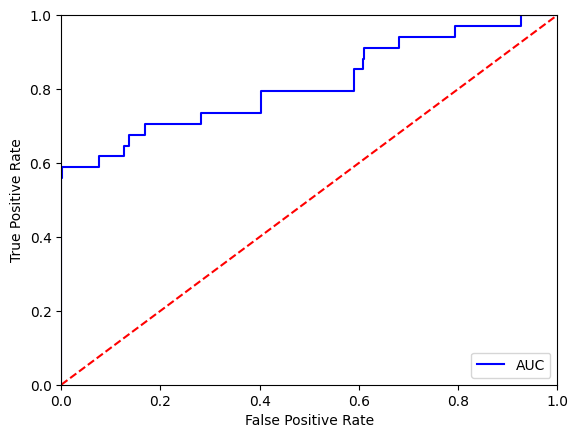

Accuracy for STDNN on Morgan Fingerprint: 0.9452054794520548
Brier for STDNN on Morgan Fingerprint: 0.0547945205479452
F1 for STDNN on Morgan Fingerprint: 0.2380952380952381
 True Positive: 0.13513513513513514
 True Negative: 1.0
False Positive: 0.0
False Negative: 0.8648648648648649
Test ROC AUC (NR-Aromatase): 0.8264736400019763


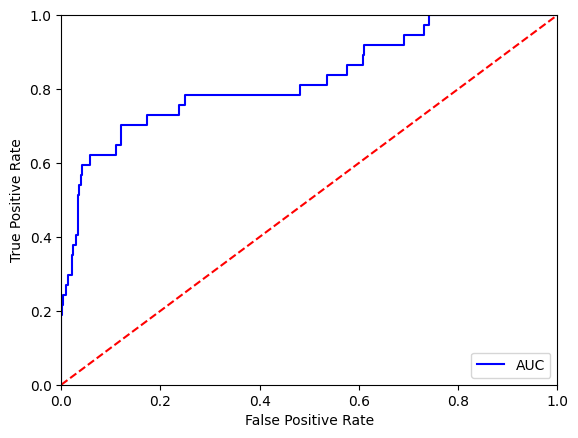

Accuracy for STDNN on Morgan Fingerprint: 0.9722650231124808
Brier for STDNN on Morgan Fingerprint: 0.02773497688751926
F1 for STDNN on Morgan Fingerprint: 0.18181818181818182
 True Positive: 0.125
 True Negative: 0.9936808846761453
False Positive: 0.00631911532385466
False Negative: 0.875
Test ROC AUC (NR-PPAR-gamma): 0.8684340442338073


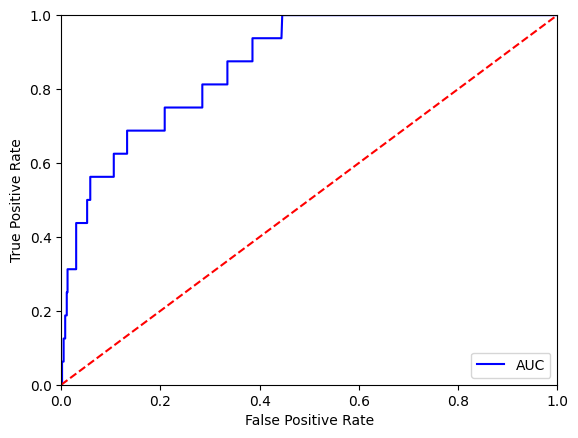

Accuracy for STDNN on Morgan Fingerprint: 0.9388379204892966
Brier for STDNN on Morgan Fingerprint: 0.06116207951070336
F1 for STDNN on Morgan Fingerprint: 0.25925925925925924
 True Positive: 0.175
 True Negative: 0.988599348534202
False Positive: 0.011400651465798045
False Negative: 0.825
Test ROC AUC (SR-HSE): 0.7322882736156352


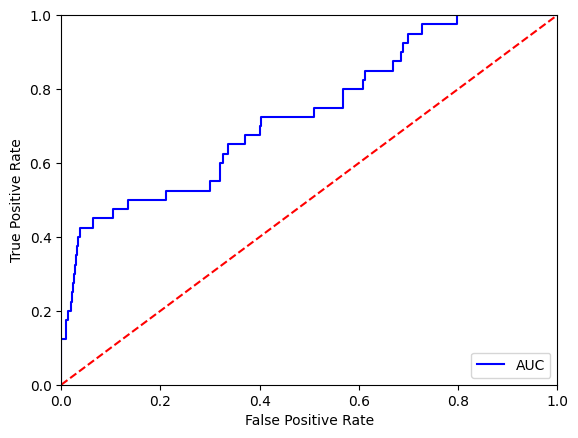

Accuracy for STDNN on Morgan Fingerprint: 0.9751098096632503
Brier for STDNN on Morgan Fingerprint: 0.024890190336749635
F1 for STDNN on Morgan Fingerprint: 0.6666666666666666
 True Positive: 0.7391304347826086
 True Negative: 0.9833333333333333
False Positive: 0.016666666666666666
False Negative: 0.2608695652173913
Test ROC AUC (NR-AR-LBD): 0.8750988142292491


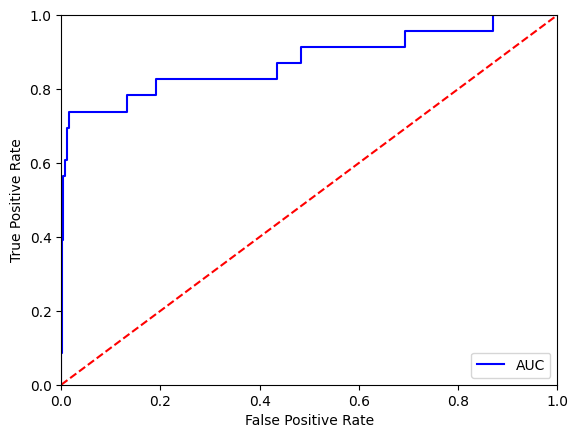

Accuracy for STDNN on Morgan Fingerprint: 0.8249211356466877
Brier for STDNN on Morgan Fingerprint: 0.1750788643533123
F1 for STDNN on Morgan Fingerprint: 0.36571428571428566
 True Positive: 0.37209302325581395
 True Negative: 0.8959854014598541
False Positive: 0.10401459854014598
False Negative: 0.627906976744186
Test ROC AUC (NR-ER): 0.6892823799015446


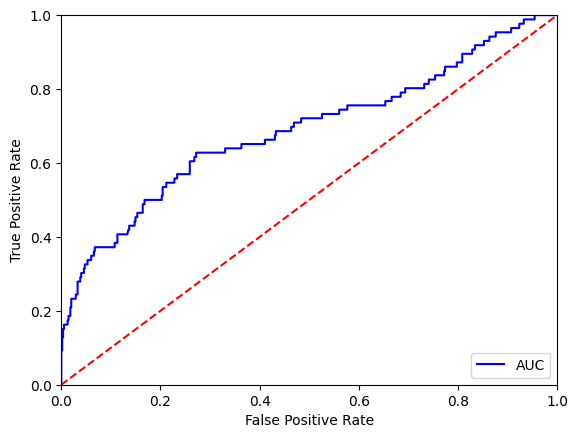

Accuracy for STDNN on Morgan Fingerprint: 0.8781302170283807
Brier for STDNN on Morgan Fingerprint: 0.12186978297161936
F1 for STDNN on Morgan Fingerprint: 0.5575757575757575
 True Positive: 0.5111111111111111
 True Negative: 0.9430255402750491
False Positive: 0.05697445972495088
False Negative: 0.4888888888888889
Test ROC AUC (SR-ARE): 0.8518445754202139


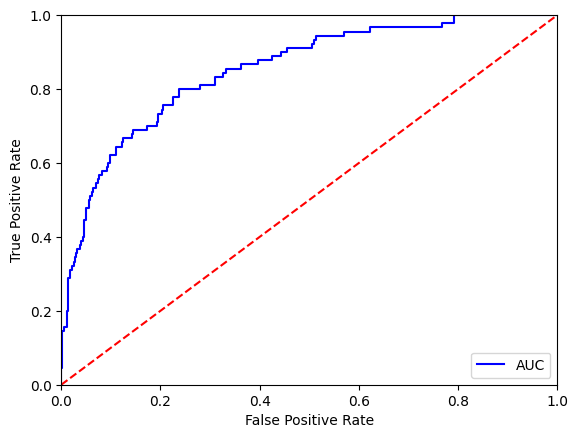

Accuracy for STDNN on Morgan Fingerprint: 0.8515901060070671
Brier for STDNN on Morgan Fingerprint: 0.14840989399293286
F1 for STDNN on Morgan Fingerprint: 0.5757575757575758
 True Positive: 0.6333333333333333
 True Negative: 0.8928571428571429
False Positive: 0.10714285714285714
False Negative: 0.36666666666666664
Test ROC AUC (SR-MMP): 0.8556489262371616


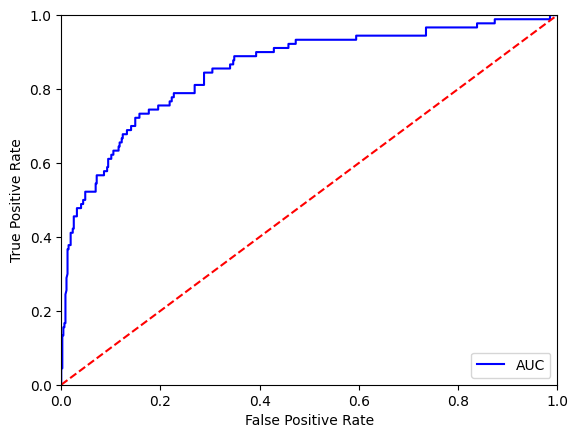

Accuracy for STDNN on Morgan Fingerprint: 0.9092284417549168
Brier for STDNN on Morgan Fingerprint: 0.0907715582450832
F1 for STDNN on Morgan Fingerprint: 0.33333333333333337
 True Positive: 0.2112676056338028
 True Negative: 0.9932203389830508
False Positive: 0.006779661016949152
False Negative: 0.7887323943661971
Test ROC AUC (NR-AhR): 0.8093339699212222


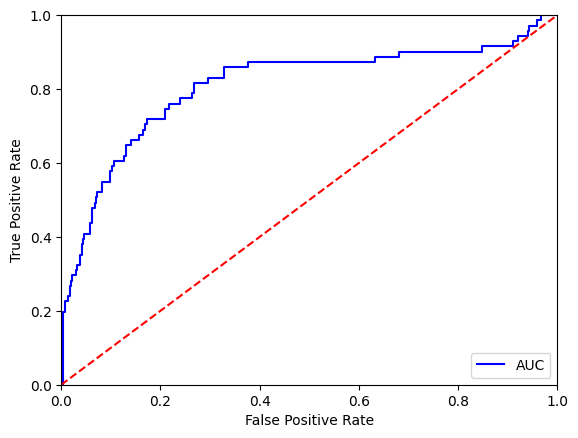

Accuracy for STDNN on Morgan Fingerprint: 0.9602272727272727
Brier for STDNN on Morgan Fingerprint: 0.03977272727272727
F1 for STDNN on Morgan Fingerprint: 0.4166666666666667
 True Positive: 0.2777777777777778
 True Negative: 0.9970059880239521
False Positive: 0.0029940119760479044
False Negative: 0.7222222222222222
Test ROC AUC (NR-ER-LBD): 0.7145708582834331


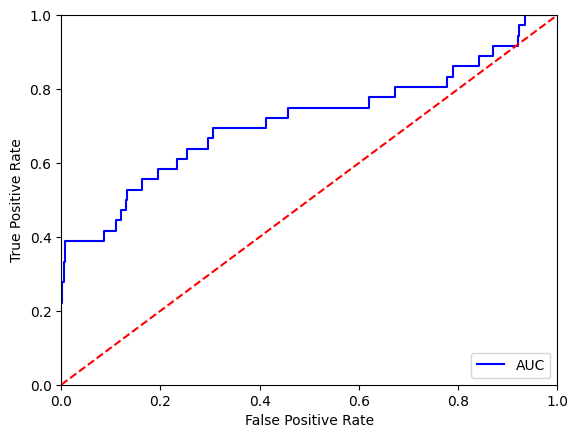

Accuracy for STDNN on Morgan Fingerprint: 0.9594972067039106
Brier for STDNN on Morgan Fingerprint: 0.040502793296089384
F1 for STDNN on Morgan Fingerprint: 0.2162162162162162
 True Positive: 0.13793103448275862
 True Negative: 0.9941775836972343
False Positive: 0.005822416302765648
False Negative: 0.8620689655172413
Test ROC AUC (SR-ATAD5): 0.706269136174271


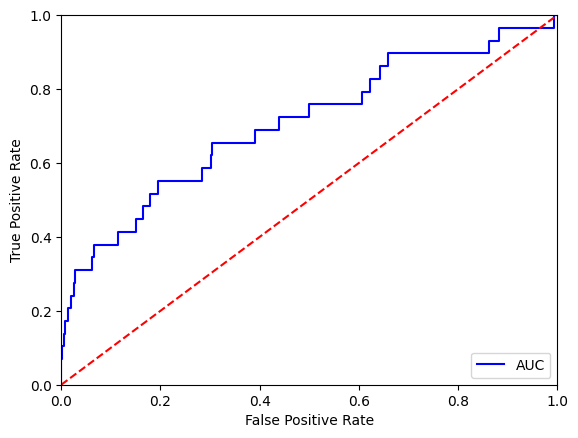

Accuracy for STDNN on Morgan Fingerprint: 0.9426470588235294
Brier for STDNN on Morgan Fingerprint: 0.057352941176470586
F1 for STDNN on Morgan Fingerprint: 0.09302325581395349
 True Positive: 0.05
 True Negative: 0.9984375
False Positive: 0.0015625
False Negative: 0.95
Test ROC AUC (SR-p53): 0.79091796875


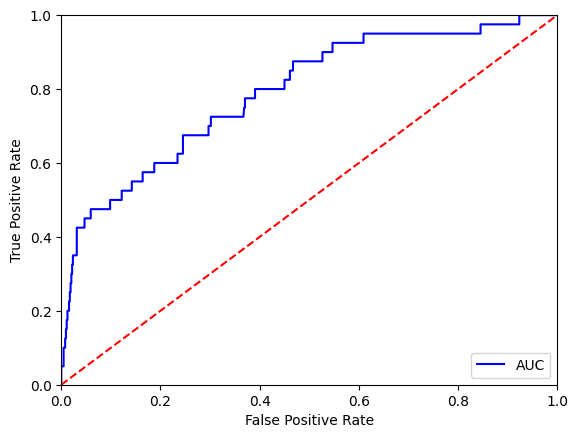

In [ ]:
from sklearn.metrics import brier_score_loss

results = {}
# Collects performance metrics for all tasks on test set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_test[:,i] >= 0
    y_test_task = y_test[valid_datapoints,i] 
    y_test_pred_task = y_test_pred[i].detach().numpy()[valid_datapoints,0]
    
    acc = accuracy_score(y_test_task, np.round(y_test_pred_task))
    print('Accuracy for STDNN on Morgan Fingerprint:', acc)

    brier = brier_score_loss(y_test_task, np.round(y_test_pred_task))
    print('Brier for STDNN on Morgan Fingerprint:', brier)
    
    bacc = sk.metrics.balanced_accuracy_score(y_test_task, np.round(y_test_pred_task))

    f1 = f1_score(y_test_task, np.round(y_test_pred_task), pos_label=1)
    print('F1 for STDNN on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_test_task, np.round(y_test_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]

    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_test_task, y_test_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results[all_tasks[i]] = [auc, acc, bacc, tn, tp, fp, fn, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_test_task, y_test_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [ ]:
print('Task'.ljust(10), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' FP  ', ' FN  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results.items():
    print(task.ljust(10), '\t', np.round(auc,3))

Task       	   AUC   ACC   BACC   TN    TP    FP    FN    PR    RC    F1  
NR-AR      	 [0.812 0.944 0.775 0.961 0.588 0.039 0.412 0.939 0.588 0.494]
NR-Aromatase 	 [0.826 0.945 0.568 1.    0.135 0.    0.865 1.    0.135 0.238]
NR-PPAR-gamma 	 [0.868 0.972 0.559 0.994 0.125 0.006 0.875 0.952 0.125 0.182]
SR-HSE     	 [0.732 0.939 0.582 0.989 0.175 0.011 0.825 0.939 0.175 0.259]
NR-AR-LBD  	 [0.875 0.975 0.861 0.983 0.739 0.017 0.261 0.978 0.739 0.667]
NR-ER      	 [0.689 0.825 0.634 0.896 0.372 0.104 0.628 0.782 0.372 0.366]
SR-ARE     	 [0.852 0.878 0.727 0.943 0.511 0.057 0.489 0.9   0.511 0.558]
SR-MMP     	 [0.856 0.852 0.763 0.893 0.633 0.107 0.367 0.855 0.633 0.576]
NR-AhR     	 [0.809 0.909 0.602 0.993 0.211 0.007 0.789 0.969 0.211 0.333]
NR-ER-LBD  	 [0.715 0.96  0.637 0.997 0.278 0.003 0.722 0.989 0.278 0.417]
SR-ATAD5   	 [0.706 0.959 0.566 0.994 0.138 0.006 0.862 0.959 0.138 0.216]
SR-p53     	 [0.791 0.943 0.524 0.998 0.05  0.002 0.95  0.97  0.05  0.093]


##### See Valid set performance

In [ ]:
# print test loss
for x_valid_torch, y_valid_torch in valid_generator:
    y_valid_pred = model.eval().to(device).cpu()(x_valid_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_valid_torch[:,i]
        y_pred_task  = y_valid_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.005486421287059784


Accuracy for deepnn on Morgan Fingerprint: 0.952755905511811
F1 for deepnn on Morgan Fingerprint: 0.39999999999999997
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.97275204 0.02724796]
 [0.57142857 0.42857143]]
 True Positive: 0.42857142857142855
 True Negative: 0.9727520435967303
False Positive: 0.027247956403269755
False Negative: 0.5714285714285714
Test ROC AUC (NR-AR): 0.7480050603347606


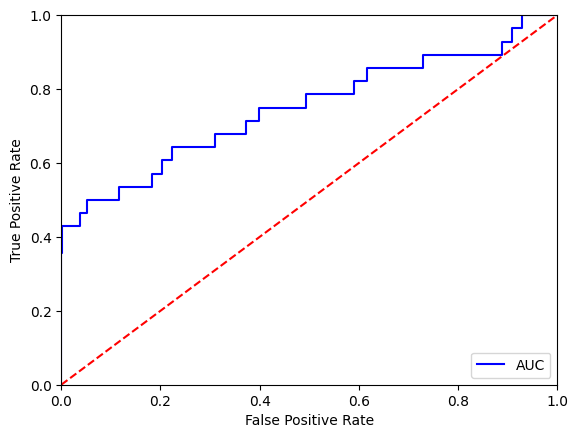

Accuracy for deepnn on Morgan Fingerprint: 0.9715242881072027
F1 for deepnn on Morgan Fingerprint: 0.4137931034482759
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99652778 0.00347222]
 [0.71428571 0.28571429]]
 True Positive: 0.2857142857142857
 True Negative: 0.9965277777777778
False Positive: 0.003472222222222222
False Negative: 0.7142857142857143
Test ROC AUC (NR-Aromatase): 0.7953042328042327


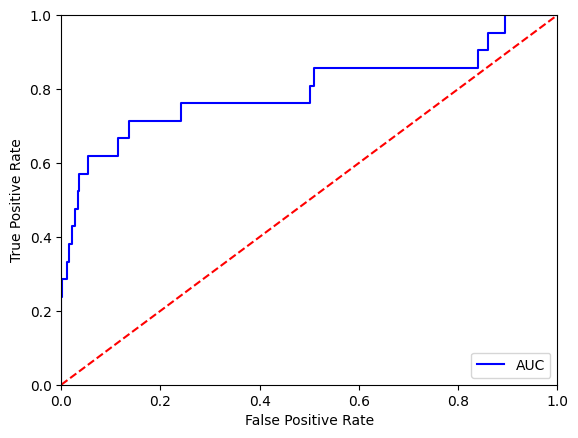

Accuracy for deepnn on Morgan Fingerprint: 0.9685157421289355
F1 for deepnn on Morgan Fingerprint: 0.16
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[1.         0.        ]
 [0.91304348 0.08695652]]
 True Positive: 0.08695652173913043
 True Negative: 1.0
False Positive: 0.0
False Negative: 0.9130434782608695
Test ROC AUC (NR-PPAR-gamma): 0.9064272211720227


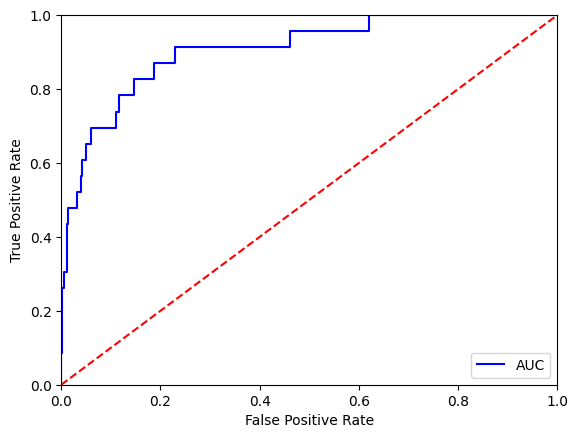

Accuracy for deepnn on Morgan Fingerprint: 0.9457013574660633
F1 for deepnn on Morgan Fingerprint: 0.35714285714285715
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.98878205 0.01121795]
 [0.74358974 0.25641026]]
 True Positive: 0.2564102564102564
 True Negative: 0.9887820512820513
False Positive: 0.011217948717948718
False Negative: 0.7435897435897436
Test ROC AUC (SR-HSE): 0.8249506903353057


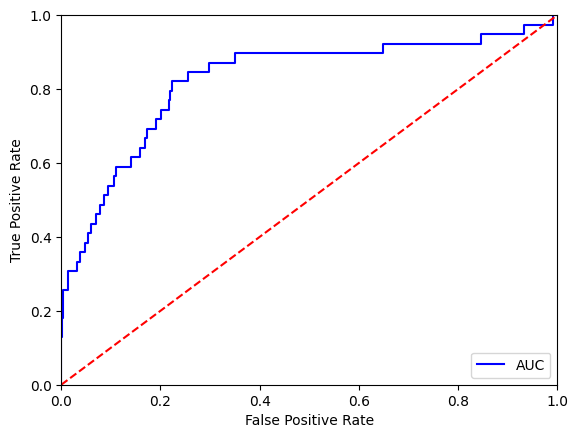

Accuracy for deepnn on Morgan Fingerprint: 0.9814020028612304
F1 for deepnn on Morgan Fingerprint: 0.6486486486486486
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99704142 0.00295858]
 [0.47826087 0.52173913]]
 True Positive: 0.5217391304347826
 True Negative: 0.9970414201183432
False Positive: 0.0029585798816568047
False Negative: 0.4782608695652174
Test ROC AUC (NR-AR-LBD): 0.9296372523797273


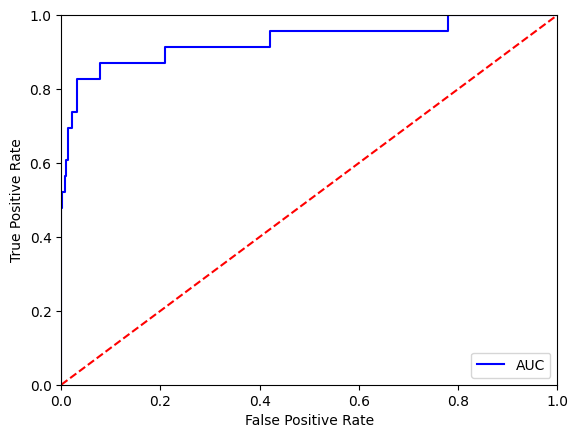

Accuracy for deepnn on Morgan Fingerprint: 0.8582434514637904
F1 for deepnn on Morgan Fingerprint: 0.39473684210526316
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.92294221 0.07705779]
 [0.61538462 0.38461538]]
 True Positive: 0.38461538461538464
 True Negative: 0.9229422066549913
False Positive: 0.07705779334500876
False Negative: 0.6153846153846154
Test ROC AUC (NR-ER): 0.6587071714041942


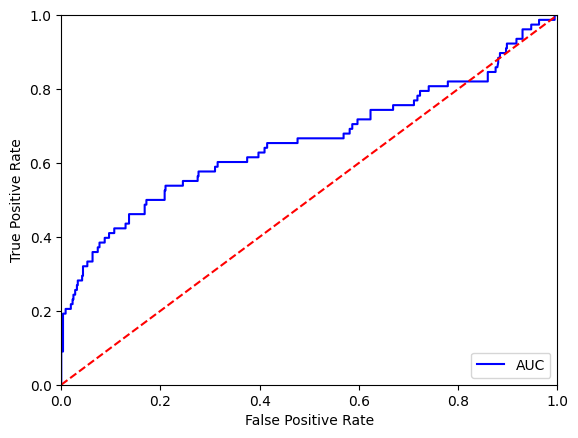

Accuracy for deepnn on Morgan Fingerprint: 0.8631051752921536
F1 for deepnn on Morgan Fingerprint: 0.4675324675324675
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.96007984 0.03992016]
 [0.63265306 0.36734694]]
 True Positive: 0.3673469387755102
 True Negative: 0.9600798403193613
False Positive: 0.03992015968063872
False Negative: 0.6326530612244898
Test ROC AUC (SR-ARE): 0.7886777465477209


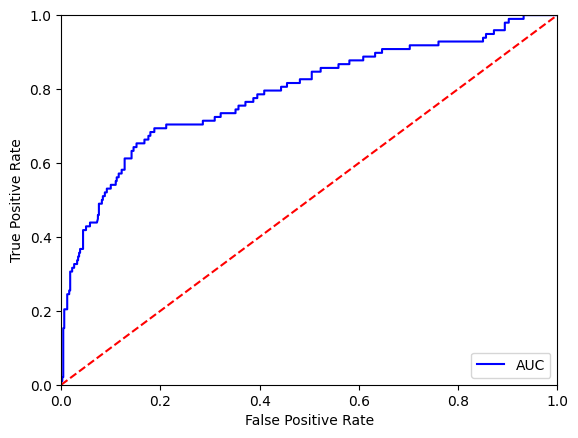

Accuracy for deepnn on Morgan Fingerprint: 0.8349673202614379
F1 for deepnn on Morgan Fingerprint: 0.5910931174089068
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.86220472 0.13779528]
 [0.29807692 0.70192308]]
 True Positive: 0.7019230769230769
 True Negative: 0.8622047244094488
False Positive: 0.1377952755905512
False Negative: 0.2980769230769231
Test ROC AUC (SR-MMP): 0.8865933525136281


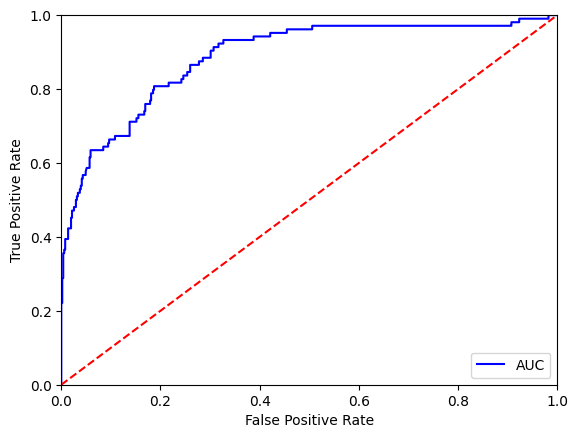

Accuracy for deepnn on Morgan Fingerprint: 0.8982558139534884
F1 for deepnn on Morgan Fingerprint: 0.37500000000000006
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99004975 0.00995025]
 [0.75294118 0.24705882]]
 True Positive: 0.24705882352941178
 True Negative: 0.9900497512437811
False Positive: 0.009950248756218905
False Negative: 0.7529411764705882
Test ROC AUC (NR-AhR): 0.8375573114818067


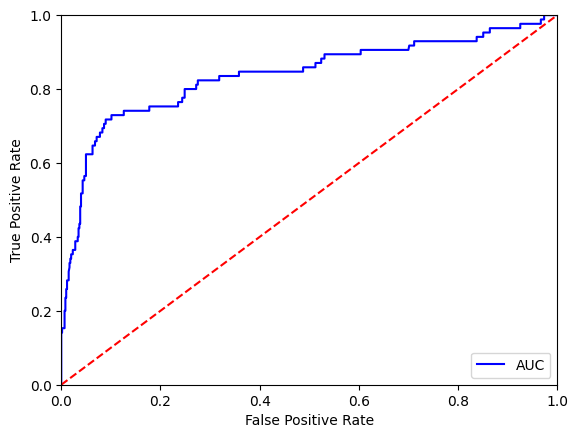

Accuracy for deepnn on Morgan Fingerprint: 0.9641873278236914
F1 for deepnn on Morgan Fingerprint: 0.35000000000000003
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.9971223  0.0028777 ]
 [0.77419355 0.22580645]]
 True Positive: 0.22580645161290322
 True Negative: 0.9971223021582734
False Positive: 0.0028776978417266188
False Negative: 0.7741935483870968
Test ROC AUC (NR-ER-LBD): 0.7282200046414482


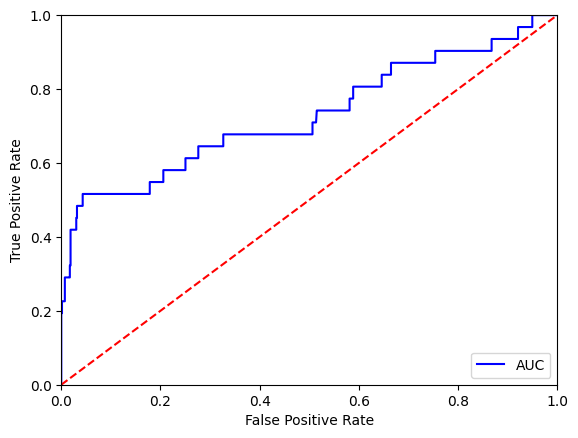

Accuracy for deepnn on Morgan Fingerprint: 0.964625850340136
F1 for deepnn on Morgan Fingerprint: 0.4090909090909091
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.9929078 0.0070922]
 [0.7       0.3      ]]
 True Positive: 0.3
 True Negative: 0.9929078014184397
False Positive: 0.0070921985815602835
False Negative: 0.7
Test ROC AUC (SR-ATAD5): 0.8743026004728133


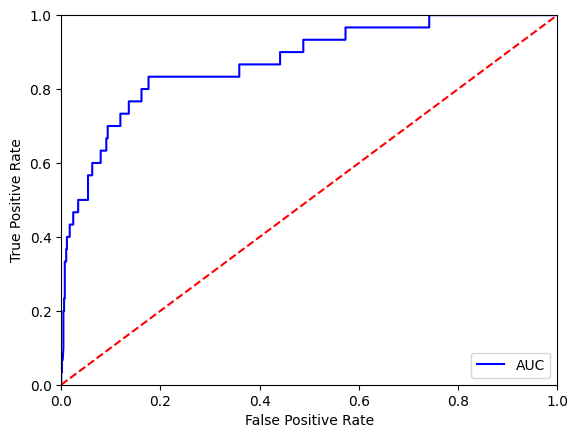

Accuracy for deepnn on Morgan Fingerprint: 0.9444444444444444
F1 for deepnn on Morgan Fingerprint: 0.1702127659574468
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99848485 0.00151515]
 [0.9047619  0.0952381 ]]
 True Positive: 0.09523809523809523
 True Negative: 0.9984848484848485
False Positive: 0.0015151515151515152
False Negative: 0.9047619047619048
Test ROC AUC (SR-p53): 0.713023088023088


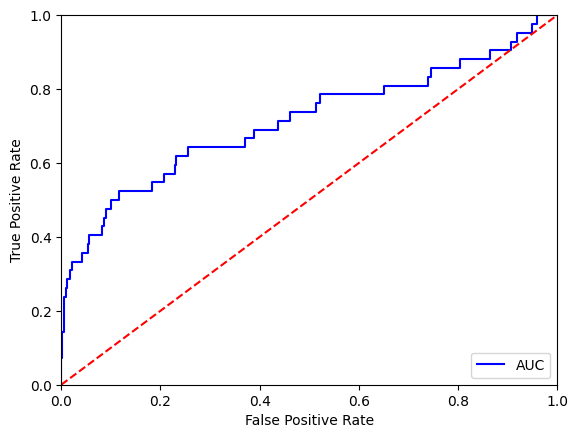

In [ ]:
results_valid = {}
# Collects performance metrics for all tasks on Valid set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_valid[:,i] >= 0
    y_valid_task = y_valid[valid_datapoints,i] 
    y_valid_pred_task = y_valid_pred[i].detach().numpy()[valid_datapoints,0]
    
    
    acc = accuracy_score(y_valid_task, np.round(y_valid_pred_task))
    print('Accuracy for deepnn on Morgan Fingerprint:', acc)
    
    bacc = sk.metrics.balanced_accuracy_score(y_valid_task, np.round(y_valid_pred_task))

    f1 = f1_score(y_valid_task, np.round(y_valid_pred_task), pos_label=1)
    print('F1 for deepnn on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_valid_task, np.round(y_valid_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]

    print('Confusion Matrix for deepnn on Morgan Fingerprint:\n', cfm)

    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_valid_task, y_valid_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results_valid[all_tasks[i]] = [auc, acc, bacc, tn, tp, fp, fn, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_valid_task, y_valid_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [ ]:
print('Task'.ljust(35), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' FP  ', ' FN  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results_valid.items():
    print(task.ljust(35), '\t', np.round(auc,3))

Task                                	   AUC   ACC   BACC   TN    TP    FP    FN    PR    RC    F1  
NR-AR                               	 [0.748 0.953 0.701 0.973 0.429 0.027 0.571 0.94  0.429 0.4  ]
NR-Aromatase                        	 [0.795 0.972 0.641 0.997 0.286 0.003 0.714 0.988 0.286 0.414]
NR-PPAR-gamma                       	 [0.906 0.969 0.543 1.    0.087 0.    0.913 1.    0.087 0.16 ]
SR-HSE                              	 [0.825 0.946 0.623 0.989 0.256 0.011 0.744 0.958 0.256 0.357]
NR-AR-LBD                           	 [0.93  0.981 0.759 0.997 0.522 0.003 0.478 0.994 0.522 0.649]
NR-ER                               	 [0.659 0.858 0.654 0.923 0.385 0.077 0.615 0.833 0.385 0.395]
SR-ARE                              	 [0.789 0.863 0.664 0.96  0.367 0.04  0.633 0.902 0.367 0.468]
SR-MMP                              	 [0.887 0.835 0.782 0.862 0.702 0.138 0.298 0.836 0.702 0.591]
NR-AhR                              	 [0.838 0.898 0.619 0.99  0.247 0.01  0.753 0.961 0.247 0.375]


In [ ]:
# Train and save 12 separate models for each task
tasks = ['task1', 'task2', 'task3', 'task4', 'task5', 'task6', 'task7', 'task8', 'task9', 'task10', 'task11', 'task12']
for task in tasks:
    model = create_model_for_task(task)  # Replace with actual model creation function
    model.fit(train_data[task], train_labels[task], epochs=10, batch_size=32)  # Adjust parameters as needed
    model.save(f"model_{task}.h5")
    print(f"Model for {task} saved.")

In [ ]:
# Train models with pos_weight variations and plot metrics
import pandas as pd
import matplotlib.pyplot as plt

pos_weights = [1, 2, 5, 10, 20, 30, 40, 50]
metrics = []

for weight in pos_weights:
    model = create_model_with_pos_weight(weight)  # Replace with actual model creation function
    history = model.fit(train_data, train_labels, epochs=10, batch_size=32)  # Adjust parameters as needed
    results = evaluate_model(model, test_data, test_labels)  # Replace with actual evaluation function
    metrics.append({"pos_weight": weight, **results})

# Save metrics to CSV
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("metrics_pos_weights.csv", index=False)

# Plot metrics
for metric in ["TP", "TN", "FP", "FN"]:
    plt.figure()
    plt.plot(metrics_df["pos_weight"], metrics_df[metric], marker="o")
    plt.title(f"{metric} across pos_weights")
    plt.xlabel("pos_weight")
    plt.ylabel(metric)
    plt.grid()
    plt.savefig(f"{metric}_pos_weights.png")
    plt.show()

In [ ]:
# Train the model with original fingerprints
original_model = train_model(fingerprints)
save_model(original_model, 'original_model_path')

# Permute the fingerprints
permuted_fingerprints = permute_fingerprints(fingerprints)

# Train the model with permuted fingerprints
permuted_model = train_model(permuted_fingerprints)
save_model(permuted_model, 'permuted_model_path')